A small business seeks to leverage cloud-based Business Intelligence (BI) solutions to analyze sales trends and customer behaviour without incurring costs of paid tools. The objectives include:
- Performing data analysis, such as Firebase Firestore, for storing and managing data.
- Performing data analytics and processing through free tools like Google Colab.
- Building an interactive BI dashboard using Google Data Studio for visualizing insights.
-Hosting data and dashboards using platforms like Google Drive and GitHub Pages.

In [1]:
# Install required libraries
!pip install firebase-admin pandas numpy matplotlib scikit-learn

In [2]:
import firebase_admin
from firebase_admin import credentials, firestore

if not firebase_admin._apps:
    cred = credentials.Certificate(
        "bi10-bd82d-firebase-adminsdk-fbsvc-51c8dd9811.json"
    )
    firebase_admin.initialize_app(cred)

db = firestore.client()

print("Connected Successfully")

Connected Successfully


In [3]:
# Firebase Admin SDK Setup
#
# 1. Go to Firebase Console.
# 2. Create a new project (or use an existing one).
# 3. Navigate to:
#    Project Settings -> Service Accounts
# 4. Click "Generate New Private Key".
# 5. A JSON credentials file will be downloaded.
# 6. Place the downloaded file in the project directory.
# 7. Update the path below with your JSON file name.
#
# Note:
# The JSON file is excluded from the repository using .gitignore
# because it contains private credentials and should not be shared publicly.

In [4]:
# Insert sample sales data

data = [
    {"product":"Laptop","price":150000,"quantity":1,"region":"South","date":"2026-04-01"},
    {"product":"Keyboard","price":1000,"quantity":3,"region":"North","date":"2026-04-02"},
    {"product":"Mouse","price":500,"quantity":5,"region":"East","date":"2026-04-03"},
    {"product":"Monitor","price":12000,"quantity":2,"region":"West","date":"2026-04-04"},
    {"product":"Printer","price":8000,"quantity":1,"region":"South","date":"2026-04-05"}
]

for item in data:
    db.collection("exp10").add(item)

print("Records inserted successfully")

Records inserted successfully


In [5]:
# Retrieve data from Firestore

import pandas as pd

docs = db.collection('exp10').stream()

data = [doc.to_dict() for doc in docs]

df = pd.DataFrame(data)

print(df)

   region   product  quantity   price        date
0    East     Mouse         5     500  2026-04-03
1    West   Monitor         2   12000  2026-04-04
2   South   Printer         1    8000  2026-04-05
3    West   Monitor         2   12000  2026-04-04
4   North  Keyboard         3    1000  2026-04-02
5   North  Keyboard         3    1000  2026-04-02
6   South    Laptop         1  150000  2026-04-01
7    East     Mouse         5     500  2026-04-03
8   South    Laptop         1  150000  2026-04-01
9   South    Laptop         1  150000  2026-04-01
10  North  Keyboard         3    1000  2026-04-02
11   East     Mouse         5     500  2026-04-03
12   West   Monitor         2   12000  2026-04-04
13  South   Printer         1    8000  2026-04-05
14  South   Printer         1    8000  2026-04-05


In [6]:
# Create total sales column

df['date'] = pd.to_datetime(df['date'])

df['total_sales'] = df['price'] * df['quantity']

print(df)

   region   product  quantity   price       date  total_sales
0    East     Mouse         5     500 2026-04-03         2500
1    West   Monitor         2   12000 2026-04-04        24000
2   South   Printer         1    8000 2026-04-05         8000
3    West   Monitor         2   12000 2026-04-04        24000
4   North  Keyboard         3    1000 2026-04-02         3000
5   North  Keyboard         3    1000 2026-04-02         3000
6   South    Laptop         1  150000 2026-04-01       150000
7    East     Mouse         5     500 2026-04-03         2500
8   South    Laptop         1  150000 2026-04-01       150000
9   South    Laptop         1  150000 2026-04-01       150000
10  North  Keyboard         3    1000 2026-04-02         3000
11   East     Mouse         5     500 2026-04-03         2500
12   West   Monitor         2   12000 2026-04-04        24000
13  South   Printer         1    8000 2026-04-05         8000
14  South   Printer         1    8000 2026-04-05         8000


#### Descriptive Analytics

In [7]:
# Total sales

total_sales = df['total_sales'].sum()

print("Total Sales =", total_sales)

Total Sales = 562500


In [8]:
# Product-wise sales analysis

product_sales = df.groupby('product')['total_sales'].sum()

print(product_sales)

product
Keyboard      9000
Laptop      450000
Monitor      72000
Mouse         7500
Printer      24000
Name: total_sales, dtype: int64


In [9]:
# Region-wise sales analysis

region_sales = df.groupby('region')['total_sales'].sum()

print(region_sales)

region
East       7500
North      9000
South    474000
West      72000
Name: total_sales, dtype: int64


In [10]:
# Sales trend analysis

trend = df.groupby('date')['total_sales'].sum()

print(trend)

date
2026-04-01    450000
2026-04-02      9000
2026-04-03      7500
2026-04-04     72000
2026-04-05     24000
Name: total_sales, dtype: int64


#### Predictive Analytics

In [11]:
# Predictive analytics using Linear Regression

from sklearn.linear_model import LinearRegression
import numpy as np

trend_df = trend.reset_index()

trend_df['day_num'] = np.arange(len(trend_df))

X = trend_df[['day_num']]
y = trend_df['total_sales']

model = LinearRegression()

model.fit(X, y)

future_days = np.array([
    [len(X)],
    [len(X)+1],
    [len(X)+2]
])

future_sales = model.predict(future_days)

print("Future Sales Forecast")

for i, sale in enumerate(future_sales, start=6):
    print(f"Day {i}: {sale:.2f}")

Future Sales Forecast
Day 6: -124200.00
Day 7: -203100.00
Day 8: -282000.00


c:\Users\jenis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


#### Prescriptive Analytics

In [12]:
# Prescriptive analytics

recommendations = []

top_product = product_sales.idxmax()
low_product = product_sales.idxmin()

recommendations.append("Increase inventory of " + top_product)
recommendations.append("Offer promotions on " + low_product)

for r in recommendations:
    print(r)

Increase inventory of Laptop
Offer promotions on Mouse


#### Visualization

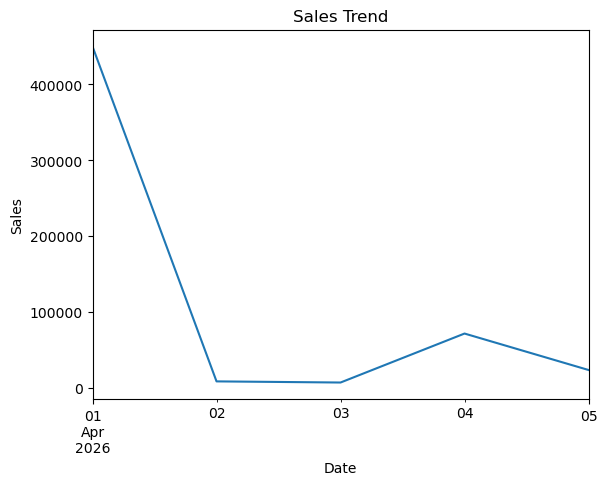

In [13]:
# Sales trend graph

import matplotlib.pyplot as plt

trend.plot(kind='line', title='Sales Trend')

plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

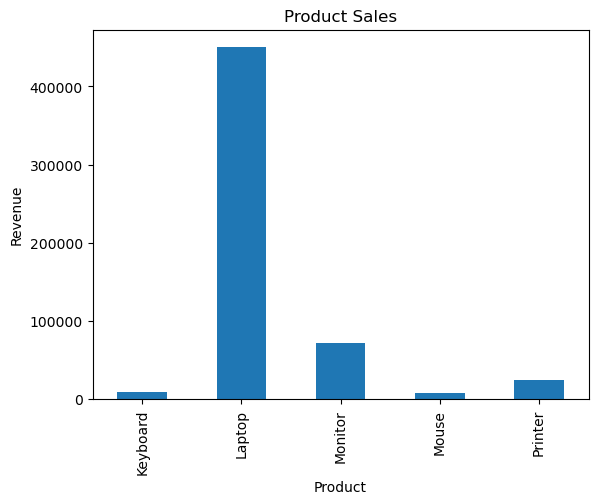

In [14]:
# Product-wise sales graph

product_sales.plot(kind='bar', title='Product Sales')

plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

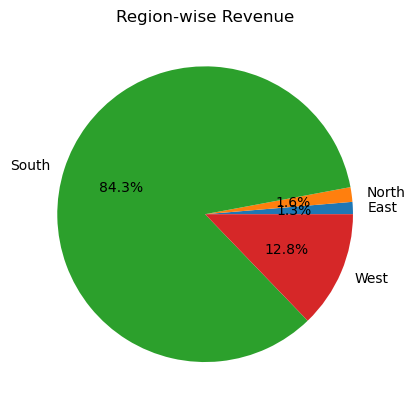

In [15]:
# Region-wise revenue graph

region_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Region-wise Revenue")

plt.ylabel("")

plt.show()

In [16]:
# Export data to CSV

df.to_csv("sales_report.csv", index=False)

print("CSV exported successfully")

CSV exported successfully
